# Модель доверия: когда можно верить AI-проверке

**Задача.** Итоговая система (Gemini с эталонными ответами) проверяет каждую задачу ученика и ставит вердикт
«верно / ошибка / не решено». Иногда она ошибается сама. Модель доверия по признакам задачи и ответа проверки оценивает
**вероятность, что проверка ошиблась**; самые подозрительные задачи уходят куратору, остальные — ученику автоматически.

**Что считаем успехом.** Не «высокий AUC», а рабочая точка: *какую долю задач смотрит куратор и сколько ошибок проверки
при этом доходит до ученика*. Порог выбираем процедурой Learn then Test.

**Правила честности:**
- только **dev** (51 работа, 883 задачи); test (27 работ) ещё не запускался — он для финальной проверки;
- кросс-валидация **по группам** (задание целиком в одном фолде), 20 повторов;
- признаки — **только те, что доступны в работающей системе**; они считаются в `trust_features.py`, тот же код
  применяется к test (`apply_trust.py`);
- сравнения — с интервалами (bootstrap по работам); всё, что решено по данным dev, помечено — это оптимизм.
  Вложенная кросс-валидация (раздел 4) проверяет обучение, порог и выбор между v1 и v2; то, что сам признак v2
  придуман после разбора ошибок dev, никакая CV на dev не проверит — это делает только test.

Содержание: 1) данные · 2) бейзлайны · 3) модели и выбор · 4) устойчивость · 5) калибровка · 6) порог ·
7) финальная модель · 8) итоги.

In [1]:
import json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import beta
import trust_features as tf

pd.set_option("display.max_columns", 80)
wide = pd.read_csv("../data/features_wide.csv")
df = wide[wide["split"] == "dev"].reset_index(drop=True)
y = df[f"{tf.MAIN}__wrong"].astype(int)
F = tf.build(df)
print(f"задач: {len(df)}, работ: {df.work.nunique()}, заданий: {df.task_key.nunique()}, учеников: {df.student_id.nunique()}")
print(f"проверка ошиблась: {y.sum()} из {len(y)} ({y.mean():.1%})")

Matplotlib is building the font cache; this may take a moment.


задач: 883, работ: 51, заданий: 32, учеников: 12
проверка ошиблась: 32 из 883 (3.6%)


## 1. Данные

Объект — размеченная задача; `y = 1`, если вердикт итоговой системы не совпал с разметкой куратора.
**Ложная тревога** — сказала «ошибка», а решение верное; **пропуск** — сказала «верно», а ошибка была.
«Не решено» считается тревогой: такую задачу куратор всё равно смотрит.

In [2]:
pe = F[f"{tf.MAIN}__pred_error"]
kind = np.select([(y == 1) & (pe == 1), (y == 1) & (pe == 0)], ["ложная тревога", "пропуск"], "проверка права")
print(pd.Series(kind).value_counts().to_string())
print("\nразборчивость (среднее по страницам работы, 0 — плохо, 2 — хорошо):",
      F["legibility_mean"].describe()[["min", "50%", "max"]].round(2).to_dict(),
      "| страниц «плохо» в dev:", int((df["legibility_min"] == 0).sum()))
print("\nошибок проверки на одну работу:")
print(df.assign(y=y).groupby("work")["y"].sum().value_counts().sort_index().rename("работ").to_string())

проверка права    851
ложная тревога     26
пропуск             6

разборчивость (среднее по страницам работы, 0 — плохо, 2 — хорошо): {'min': 1.0, '50%': 1.76, 'max': 2.0} | страниц «плохо» в dev: 0

ошибок проверки на одну работу:
y
0    29
1    17
2     2
3     1
4     2


**Главная трудность — 32 положительных примера.** Следствия, которые определяют дизайн:
1. **Любая цифра шумная** — везде интервалы и повторы кросс-валидации.
2. **Модель маленькая** — правило «~10 событий на признак» даёт 3–4 признака; гиперпараметры фиксируем заранее, а не
   подбираем (подбор на 32 примерах переобучился бы на кросс-валидации).
3. **Не обычный KFold.** Одна плохо распознанная страница даёт сразу несколько ошибок проверки; у задач одного задания
   общие условие и ключ. Поэтому `StratifiedGroupKFold` с группой = задание: в проверке — всегда новые задания.

**Признаки-кандидаты** (`trust_features.py`) — выбраны по смыслу до обучения, из того, что есть в работающей системе:

In [3]:
desc = {f"{tf.MAIN}__pred_error": "вердикт «ошибка/не решено»", "key_conflict": "вердикт спорит с ключом",
        "legibility_mean": "разборчивость (0–2)", "alarm_no_errors": "тревога без названных ошибок",
        f"{tf.MAIN}__n_err_substantive": "число названных ошибок по сути", "second_disagree": "DeepSeek не согласен"}
rows = []
for c in tf.CANDIDATES:
    a = roc_auc_score(y, F[c].fillna(F[c].median()))
    rows.append({"признак": c, "смысл": desc[c], "AUC в одиночку": round(max(a, 1 - a), 3),
                 "в финальной модели": c in tf.FEATURES})
pd.DataFrame(rows)

,признак,смысл,AUC в одиночку,в финальной модели
0,g_low_key__pred_error,вердикт «ошибка/не решено»,0.774,True
1,key_conflict,вердикт спорит с ключом,0.679,True
2,legibility_mean,разборчивость (0–2),0.651,True
3,alarm_no_errors,тревога без названных ошибок,0.593,True
4,g_low_key__n_err_substantive,число названных ошибок по сути,0.687,False
5,second_disagree,DeepSeek не согласен,0.681,False


## 2. Метрика и бейзлайны

**Главная метрика** — итоговое совпадение с разметкой, если куратор смотрит долю `b` самых подозрительных задач
(куратор решает верно; это допущение ослабляем в разделе 8). ROC-AUC от доли классов не зависит, но описывает весь
список сразу, а решение принимается в верхних 5–15% — поэтому она вспомогательная, как и PR-AUC.

**Бейзлайны** — правила без обучения. Обученная модель нужна, только если она не хуже их и даёт что-то сверх
(вероятности, порог с контролем риска).

In [4]:
BUDGETS = [0.03, 0.05, 0.10, 0.15]


def routed_accuracy(y_true, score, budget, seed=1):
    # куратору — доля budget самых подозрительных задач (ничьи разбиваем случайно), остальные — как сказала проверка
    y_true = np.asarray(y_true)
    order = np.lexsort((np.random.default_rng(seed).random(len(score)), -np.asarray(score, float)))
    return 1 - y_true[order[int(round(budget * len(y_true))):]].sum() / len(y_true)


def report(scores, y_true=y):
    rows = []
    for name, s in scores.items():
        row = {"": name, "ROC-AUC": roc_auc_score(y_true, s), "PR-AUC": average_precision_score(y_true, s)}
        row.update({f"@{int(b*100)}%": routed_accuracy(y_true, s, b) for b in BUDGETS})
        rows.append(row)
    return pd.DataFrame(rows).set_index("").round(3)


kc, ane = F["key_conflict"], F["alarm_no_errors"]
leg = F["legibility_mean"].fillna(F["legibility_mean"].median())
BASE = {
    "случайно": np.random.default_rng(0).random(len(df)),
    "все «ошибки» проверки": pe.values,
    "спор с ключом, затем «ошибка»": (2 * kc + pe).values,
    "спор с ключом или DeepSeek": (2 * kc + F["second_disagree"]).values,
    # те же 4 сигнала, что у финальной модели, веса — вручную по знакам и порядку её коэффициентов (т. е. тоже по dev)
    "правило на 4 сигналах модели": (4 * np.maximum(kc, ane) + 2 * pe - leg / 3).values,
}
print(f"без куратора: совпадение {1 - y.mean():.3f}")
report(BASE)

без куратора: совпадение 0.964


,ROC-AUC,PR-AUC,@3%,@5%,@10%,@15%
,,,,,,
случайно,0.385,0.031,0.965,0.966,0.966,0.966
все «ошибки» проверки,0.774,0.091,0.966,0.968,0.974,0.980
"спор с ключом, затем «ошибка»",0.831,0.258,0.977,0.978,0.982,0.984
спор с ключом или DeepSeek,0.750,0.292,0.977,0.978,0.984,0.985
правило на 4 сигналах модели,0.865,0.487,0.982,0.984,0.989,0.993


ROC-AUC случайного правила далеко от 0,5 — наглядно, насколько шумны метрики на 32 примерах.

In [5]:
def oof(make, X, y_true=y, groups=None, repeats=20, n_splits=5, keep=False, seed0=0):
    # out-of-fold вероятности, усреднённые по repeats разбиениям; keep=True — вернуть и модели фолдов
    groups = df["task_key"] if groups is None else groups
    y_true = pd.Series(np.asarray(y_true))
    out, models = np.zeros(len(X)), []
    for seed in range(seed0, seed0 + repeats):
        for tr, te in StratifiedGroupKFold(n_splits, shuffle=True, random_state=seed).split(X, y_true, groups):
            m = make().fit(X.iloc[tr], y_true.iloc[tr])
            out[te] += m.predict_proba(X.iloc[te])[:, 1]
            if keep:
                models.append(m)
    return (out / repeats, models) if keep else out / repeats


def paired_bootstrap(a, b, budget=0.10, n_boot=2000, seed=0):
    # разница «a − b» в итоговом совпадении при бюджете; bootstrap по работам (обе оценки на одних и тех же работах)
    rnd, works, yv = np.random.default_rng(seed), df["work"].values, y.values
    idx = {w: np.where(works == w)[0] for w in np.unique(works)}
    keys = list(idx)
    d = []
    for _ in range(n_boot):
        s = np.concatenate([idx[w] for w in rnd.choice(keys, len(keys))])
        d.append(routed_accuracy(yv[s], a[s], budget) - routed_accuracy(yv[s], b[s], budget))
    return np.mean(d), *np.percentile(d, [2.5, 97.5])


for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=0).split(df, y, df["task_key"]):
    assert not set(df.task_key[tr]) & set(df.task_key[te])
print("групповые фолды проверены: ни одно задание не попадает и в обучение, и в проверку")

групповые фолды проверены: ни одно задание не попадает и в обучение, и в проверку


## 3. Модели и выбор

Кандидаты (гиперпараметры фиксированы заранее):
- **логрег v1** — вердикт, спор с ключом, разборчивость, число названных ошибок (как задумано изначально);
- **логрег v1 + DeepSeek** — сколько даёт второй голос (он стоит ≈ 1,2 ₽ и отдельного прогона на работу);
- **бустинг v1 + DeepSeek** (глубина 2, сильная регуляризация) — есть ли нелинейности;
- **логрег v2** — v1, где число ошибок заменено индикатором «тревога без названных ошибок» (почему — ниже);
- **логрег v2 + DeepSeek** — честная пара для решения о втором голосе (тот же набор, плюс один признак).

In [6]:
def logreg(cols, C=1.0):
    return lambda: make_pipeline(ColumnTransformer([("x", make_pipeline(SimpleImputer(strategy="median"),
                                                                        StandardScaler()), cols)]),
                                 LogisticRegression(C=C, max_iter=2000))


def boosting(cols):
    return lambda: make_pipeline(ColumnTransformer([("x", "passthrough", cols)]),
                                 HistGradientBoostingClassifier(max_depth=2, learning_rate=0.05, max_iter=150,
                                                                min_samples_leaf=20, l2_regularization=1.0, random_state=0))

V1 = [f"{tf.MAIN}__pred_error", "key_conflict", "legibility_mean", f"{tf.MAIN}__n_err_substantive"]
MODELS = {"логрег v1": logreg(V1),
          "логрег v1 + DeepSeek": logreg(V1 + ["second_disagree"]),
          "бустинг v1 + DeepSeek": boosting(V1 + ["second_disagree"]),
          "логрег v2 (финальная)": logreg(tf.FEATURES),
          "логрег v2 + DeepSeek": logreg(tf.FEATURES + ["second_disagree"])}
OOF = {}
for name, make in MODELS.items():
    t = time.time(); OOF[name] = oof(make, F); print(f"{name}: {time.time() - t:.0f} с")
report({k: BASE[k] for k in ["спор с ключом, затем «ошибка»", "спор с ключом или DeepSeek",
                              "правило на 4 сигналах модели"]} | OOF)

логрег v1: 0 с


логрег v1 + DeepSeek: 0 с


бустинг v1 + DeepSeek: 5 с


логрег v2 (финальная): 0 с


логрег v2 + DeepSeek: 0 с


,ROC-AUC,PR-AUC,@3%,@5%,@10%,@15%
,,,,,,
"спор с ключом, затем «ошибка»",0.831,0.258,0.977,0.978,0.982,0.984
спор с ключом или DeepSeek,0.750,0.292,0.977,0.978,0.984,0.985
правило на 4 сигналах модели,0.865,0.487,0.982,0.984,0.989,0.993
логрег v1,0.819,0.389,0.978,0.981,0.986,0.992
логрег v1 + DeepSeek,0.841,0.395,0.977,0.983,0.988,0.991
бустинг v1 + DeepSeek,0.822,0.412,0.980,0.982,0.988,0.991
логрег v2 (финальная),0.854,0.464,0.981,0.983,0.990,0.993
логрег v2 + DeepSeek,0.854,0.478,0.982,0.984,0.988,0.992


**Почему v2.** В v1 число названных ошибок входило линейно с отрицательным коэффициентом, и это давало артефакт:
задача W062 Б1-9 (спор с ключом, DeepSeek не согласен, названо 4 ошибки — все порождены неверным распознаванием)
получала самую низкую оценку из всех. Разбор показал, что сигнал на самом деле — в другом: тревога **без единой
названной ошибки** (в основном «не решено») ошибочна в 6 случаях из 8, а при одной и более названных ошибках —
в 20 из 243. Поэтому признак заменён индикатором. Это решение принято по данным dev (оптимизм!), поэтому полный
конвейер проверяется вложенной кросс-валидацией в разделе 4, а окончательно — на test.

In [7]:
ne = F[f"{tf.MAIN}__n_err_substantive"]
print(pd.crosstab(np.where(pe == 0, "верно", np.where(ne == 0, "тревога, 0 ошибок", "тревога, ≥1 ошибки")), y,
                  margins=True).rename(columns={0: "проверка права", 1: "проверка ошиблась"}).to_string())

g_low_key__wrong    проверка права  проверка ошиблась  All
row_0                                                     
верно                          626                  6  632
тревога, 0 ошибок                2                  6    8
тревога, ≥1 ошибки             223                 20  243
All                            851                 32  883


In [8]:
FINAL = "логрег v2 (финальная)"
for b in (0.05, 0.10, 0.15):
    for name, other in [("правило «спор с ключом, затем ошибка»", BASE["спор с ключом, затем «ошибка»"]),
                        ("правило на 4 сигналах модели", BASE["правило на 4 сигналах модели"]),
                        ("правило с DeepSeek", BASE["спор с ключом или DeepSeek"]),
                        ("логрег v1", OOF["логрег v1"])]:
        m, lo, hi = paired_bootstrap(OOF[FINAL], other, b)
        print(f"@{int(b*100):2d}%  финальная − {name:38s} {100*m:+.2f} п.п. [{100*lo:+.2f}; {100*hi:+.2f}]")
    m, lo, hi = paired_bootstrap(OOF["логрег v2 + DeepSeek"], OOF[FINAL], b)
    print(f"@{int(b*100):2d}%  (v2 + DeepSeek) − финальная{'':25s} {100*m:+.2f} п.п. [{100*lo:+.2f}; {100*hi:+.2f}]")
    print()

@ 5%  финальная − правило «спор с ключом, затем ошибка»  +0.52 п.п. [+0.12; +0.97]


@ 5%  финальная − правило на 4 сигналах модели           -0.05 п.п. [-0.27; +0.11]
@ 5%  финальная − правило с DeepSeek                     +0.47 п.п. [+0.00; +0.93]


@ 5%  финальная − логрег v1                              +0.30 п.п. [-0.11; +0.74]


@ 5%  (v2 + DeepSeek) − финальная                          +0.02 п.п. [-0.36; +0.40]



@10%  финальная − правило «спор с ключом, затем ошибка»  +0.69 п.п. [+0.12; +1.30]


...

@10%  финальная − логрег v1                              +0.25 п.п. [+0.00; +0.64]


@10%  (v2 + DeepSeek) − финальная                          -0.09 п.п. [-0.66; +0.43]

@15%  финальная − правило «спор с ключом, затем ошибка»  +0.68 п.п. [+0.11; +1.36]


@15%  финальная − правило на 4 сигналах модели           -0.00 п.п. [-0.12; +0.12]
@15%  финальная − правило с DeepSeek                     +0.69 п.п. [-0.12; +1.62]


@15%  финальная − логрег v1                              +0.16 п.п. [-0.00; +0.55]


@15%  (v2 + DeepSeek) − финальная                          -0.05 п.п. [-0.56; +0.33]



In [9]:
m = MODELS[FINAL]().fit(F, y)
lr, sc = m[-1], m[0].named_transformers_["x"][-1]
coef = pd.DataFrame({"стандартизованный": lr.coef_[0], "на единицу признака": lr.coef_[0] / sc.scale_}, index=tf.FEATURES)
print("коэффициенты финальной модели (+ повышает подозрение, что проверка ошиблась):")
print(coef.round(3).to_string())

коэффициенты финальной модели (+ повышает подозрение, что проверка ошиблась):
                       стандартизованный  на единицу признака
g_low_key__pred_error              0.715                1.586
key_conflict                       0.551                3.261
legibility_mean                   -0.492               -1.490
alarm_no_errors                    0.378                3.989


### 3б. Больше примеров: учимся на ошибках всех прогонов

Те же задачи проверяли и другие «проверяющие» (Gemini без ключа, с разным думанием, другие промпты, DeepSeek) — это
289 ошибок проверки вместо 32. Строка = (задача, прогон); настройки прогона — тоже признаки; «второе мнение» — вердикт
другой модели. Обучаем на всех прогонах, **оцениваем только на итоговой системе** на тех же фолдах (одна задача во
всех прогонах — в одном фолде, иначе утечка).

In [10]:
long = pd.read_csv("../data/features.csv")
RUNS = ["google_gemini-3.8-flash@low", "google_gemini-3.8-flash@low_key", "deepseek_deepseek-v4.1-flash@high_img",
        "google_gemini-3.8-flash@minimal", "google_gemini-3.8-flash@medium", "google_gemini-3.8-flash@high",
        "google_gemini-3.8-flash@low_key_v2", "google_gemini-3.8-flash@low_key_v3"]
EVAL_RUN = "google_gemini-3.8-flash@low_key"
long = long[long.run.isin(RUNS) & (long.split == "dev") & long.model_wrong.notna()].copy()
long["key"] = long.work + "|" + long.task_no.astype(str)
verdict = long.pivot_table(index="key", columns="run", values="pred_error", aggfunc="first")
partner = np.where(long.run.str.startswith("deepseek"), EVAL_RUN, "deepseek_deepseek-v4.1-flash@high_img")
long["partner_pred"] = [verdict.at[k, p] for k, p in zip(long.key, partner)]
long["second_disagree"] = ((long.partner_pred != long.pred_error) & long.partner_pred.notna()).astype(int)
long["key_conflict"] = (((long.pred_error == 1) & (long.key_vs_student == 1)) |
                        ((long.pred_error == 0) & (long.key_vs_student == 0))).astype(int)
long["alarm_no_errors"] = ((long.pred_error == 1) & (long.n_err_substantive.fillna(0) == 0)).astype(int)
long["is_deepseek"] = long.run.str.startswith("deepseek").astype(int)
long["prompt_v"] = long.run.str.extract(r"_v(\d)$")[0].fillna(1).astype(int)
long["effort_num"] = long.effort_check.map({"minimal": 0, "low": 1, "medium": 2, "high": 3, "default": 1})
long["model_wrong"] = long.model_wrong.astype(int)
LCOLS = ["pred_error", "key_conflict", "legibility_mean", "alarm_no_errors", "second_disagree",
         "check_with_key", "check_images", "is_deepseek", "prompt_v", "effort_num"]
print(long.groupby("run").model_wrong.agg(["size", "sum"]).to_string()); print("всего ошибок проверки:", long.model_wrong.sum())

ev = long[long.run == EVAL_RUN].set_index("key")
dkey = (df.work + "|" + df.task_no.astype(str)).values
assert set(dkey) <= set(ev.index)


def oof_long(make, cols, repeats=20):
    out = np.zeros(len(df))
    for seed in range(repeats):
        for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=seed).split(df, y, df.task_key):
            rows = long[long.task_key.isin(set(df.task_key[tr]))]
            out[te] += make().fit(rows[cols], rows.model_wrong).predict_proba(ev.loc[dkey[te], cols])[:, 1]
    return out / repeats

OOF["3б: логрег, все прогоны"] = oof_long(logreg(LCOLS), LCOLS)
OOF["3б: бустинг, все прогоны"] = oof_long(boosting(LCOLS), LCOLS)
report({k: OOF[k] for k in [FINAL, "3б: логрег, все прогоны", "3б: бустинг, все прогоны"]})

                                       size  sum
run                                             
deepseek_deepseek-v4.1-flash@high_img   881   82
google_gemini-3.8-flash@high             79    6
google_gemini-3.8-flash@low             870   98
google_gemini-3.8-flash@low_key         883   32
google_gemini-3.8-flash@low_key_v2      130    5
google_gemini-3.8-flash@low_key_v3      883   42
google_gemini-3.8-flash@medium          130   11
google_gemini-3.8-flash@minimal         130   13
всего ошибок проверки: 289


,ROC-AUC,PR-AUC,@3%,@5%,@10%,@15%
,,,,,,
логрег v2 (финальная),0.854,0.464,0.981,0.983,0.990,0.993
"3б: логрег, все прогоны",0.866,0.464,0.980,0.983,0.986,0.989
"3б: бустинг, все прогоны",0.827,0.400,0.981,0.983,0.988,0.992


In [11]:
for name in ["3б: логрег, все прогоны", "3б: бустинг, все прогоны"]:
    m_, lo, hi = paired_bootstrap(OOF[name], OOF[FINAL], 0.10)
    print(f"@10%  {name} − финальная: {100*m_:+.2f} п.п. [{100*lo:+.2f}; {100*hi:+.2f}]")

@10%  3б: логрег, все прогоны − финальная: -0.18 п.п. [-0.78; +0.42]


@10%  3б: бустинг, все прогоны − финальная: -0.22 п.п. [-0.84; +0.38]


**Решение по моделям** (правило: при статистической ничьей — самая простая и дешёвая система):
- второй голос (DeepSeek) значимого выигрыша не даёт (пара «v2 + DeepSeek» против v2: +0,02 п.п. [−0,36; +0,40]
  при 5%, −0,09 [−0,66; +0,43] при 10%) — не входит
  в систему (экономия прогона и ≈ 1,2 ₽ на работу);
- бустинг и обучение на всех прогонах — в пределах шума, сложнее → нет;
- **логрег v2 на 4 признаках** — финальная. Она лучше грубого правила «спор с ключом, затем ошибка» за счёт признака
  «тревога без названных ошибок», найденного на dev. Правило на тех же четырёх сигналах с весами вручную даёт то же
  (разница −0,05 п.п. [−0,27; +0,11] при 5% и −0,02 [−0,20; +0,13] при 10%): **выигрыш — от сигналов, а не от обучения весов.** Ценность модели — в вероятностях
  вместо ранга, в пороге с контролем риска (Learn then Test требует оценку, а не ранг) и в том, что новые сигналы
  добавляются без ручной подгонки весов.

## 4. Устойчивость

(а) Другая группировка — по ученикам. (б) **Вложенная кросс-валидация полного конвейера**: внутри внешнего фолда —
обучение, out-of-fold оценки, порог Learn then Test и ансамбль фолд-моделей; на отложенном внешнем фолде — риск и
доля к куратору. Второй вариант — ещё и **выбор между v1 и v2 внутри внешнего фолда** (по итоговому совпадению при
бюджете 10% на внутренних out-of-fold оценках). Это честная оценка процедуры «выбор модели + обучение + порог». Не
покрыто одно: сам признак «тревога без названных ошибок» придуман после разбора ошибок всего dev.
(в) Что модель не ловит.

In [12]:
s_student = oof(MODELS[FINAL], F, groups=df["student_id"])
print("группы = задания:", report({"": OOF[FINAL]}).iloc[0].to_dict())
print("группы = ученики:", report({"": s_student}).iloc[0].to_dict())

группы = задания: {'ROC-AUC': 0.854, 'PR-AUC': 0.464, '@3%': 0.981, '@5%': 0.983, '@10%': 0.99, '@15%': 0.993}
группы = ученики: {'ROC-AUC': 0.833, 'PR-AUC': 0.469, '@3%': 0.981, '@5%': 0.983, '@10%': 0.99, '@15%': 0.991}


In [13]:
def cp_upper(k, n, delta):
    return 1.0 if k == n else beta.ppf(1 - delta, k + 1, n - k)


def ltt_threshold(p, y_true, alpha, delta=0.1):
    # самый мягкий порог, при котором верхняя (1−δ)-граница доли пропущенных ошибок проверки среди ВСЕХ задач ≤ α;
    # идём от строгих порогов к мягким, первая неудача останавливает (fixed-sequence testing)
    best, y_true = None, np.asarray(y_true)
    for t in np.sort(np.unique(p)):
        if cp_upper(int(y_true[p <= t].sum()), len(p), delta) <= alpha:
            best = t
        else:
            break
    return best


ALPHA, DELTA = 0.02, 0.1        # выбрано в TEST_PROTOCOL.md
outer, outer_sel, chosen = [], [], []
for rep in range(10):
    for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=1000 + rep).split(df, y, df.task_key):
        Ftr, ytr, gtr = F.iloc[tr].reset_index(drop=True), y.iloc[tr].reset_index(drop=True), df.task_key.iloc[tr].reset_index(drop=True)
        inner = {}
        for name in ("логрег v1", FINAL):   # при равенстве max берёт первый ключ — v1
            p_in, ms = oof(MODELS[name], Ftr, ytr, gtr, repeats=5, keep=True)
            inner[name] = (routed_accuracy(ytr, p_in, 0.10), p_in, ms)
        for store, name in ((outer, FINAL), (outer_sel, max(inner, key=lambda k: inner[k][0]))):
            _, p_in, ms = inner[name]
            t = ltt_threshold(p_in, ytr.values, ALPHA, DELTA)
            auto = np.mean([m_.predict_proba(F.iloc[te])[:, 1] for m_ in ms], axis=0) <= t  # как tf.predict, для любого набора
            store.append({"риск": y.values[te][auto].sum() / len(te), "к куратору": 1 - auto.mean()})
        chosen.append(max(inner, key=lambda k: inner[k][0]))
outer, outer_sel = pd.DataFrame(outer), pd.DataFrame(outer_sel)
print(f"выбор внутри фолда: v2 выбрана в {chosen.count(FINAL)} из {len(chosen)} внешних фолдов")
print(f"с выбором модели внутри фолда: риск в среднем {outer_sel['риск'].mean():.4f}, к куратору "
      f"{outer_sel['к куратору'].mean():.3f} [{outer_sel['к куратору'].quantile(.025):.3f}; {outer_sel['к куратору'].quantile(.975):.3f}]; "
      f"итоговое совпадение {1 - outer_sel['риск'].mean():.3f}")
print("только финальная модель:")
print(f"50 внешних фолдов: риск (доля задач с непойманной ошибкой проверки) в среднем {outer['риск'].mean():.4f}, "
      f"95-й перцентиль {outer['риск'].quantile(.95):.4f}, превышает α = {ALPHA} в {(outer['риск'] > ALPHA).mean():.0%} фолдов")
print(f"к куратору: в среднем {outer['к куратору'].mean():.3f} [{outer['к куратору'].quantile(.025):.3f}; {outer['к куратору'].quantile(.975):.3f}]")
# на отдельном фолде ~177 задач, поэтому наблюдаемый риск шумный: какая доля фолдов превышала бы α чисто случайно,
# если истинный риск равен среднему по фолдам?
from scipy.stats import binom
n_fold, r_mean = len(df) / 5, outer["риск"].mean()
print(f"ожидаемая доля фолдов с наблюдаемым риском > α только из-за выборочного шума: "
      f"{binom.sf(int(ALPHA * n_fold), int(n_fold), r_mean):.0%} (истинный риск {r_mean:.4f}, {int(n_fold)} задач в фолде)")

выбор внутри фолда: v2 выбрана в 40 из 50 внешних фолдов
с выбором модели внутри фолда: риск в среднем 0.0136, к куратору 0.072 [0.030; 0.138]; итоговое совпадение 0.986
только финальная модель:
50 внешних фолдов: риск (доля задач с непойманной ошибкой проверки) в среднем 0.0124, 95-й перцентиль 0.0222, превышает α = 0.02 в 16% фолдов
к куратору: в среднем 0.074 [0.031; 0.138]
ожидаемая доля фолдов с наблюдаемым риском > α только из-за выборочного шума: 18% (истинный риск 0.0124, 176 задач в фолде)


**Итог вложенной CV.** С выбором v1/v2 внутри фолда (v2 выбрана в 40 из 50 фолдов): риск 1,36%, к куратору 7,2%
[3,0; 13,8], итоговое совпадение 98,6%; только v2: 1,24%, 7,4%, 98,8%. Обе процедуры держат риск ниже α = 2% в среднем;
доля фолдов с риском выше α (16%) не больше, чем дал бы один выборочный шум (18%).

### Что не ловится при рабочем пороге

In [14]:
p_main = OOF[FINAL]
t_star = ltt_threshold(p_main, y.values, ALPHA, DELTA)
ea = pd.read_csv("../reports/error_analysis_low_key_reviewed.csv", dtype=str)
cause = dict(zip(ea.work + "|" + ea.task_no, ea.cause))
missed = df[(y == 1) & (p_main <= t_star)].copy()
missed["вид"] = np.where(missed[f"{tf.MAIN}__pred_error"] == 1, "ложная тревога", "пропуск")
missed["причина (разбор)"] = [cause.get(f"{w}|{t}", "—") for w, t in zip(missed.work, missed.task_no)]
missed["DeepSeek не согласен"] = F.loc[missed.index, "second_disagree"].astype(int)
print(f"не поймано {len(missed)} из {y.sum()} ошибок проверки; поймано пропусков (вердикт «верно») "
      f"{((y == 1) & (pe == 0) & (p_main > t_star)).sum()} из {((y == 1) & (pe == 0)).sum()}")
missed[["work", "task_no", "вид", "причина (разбор)", "DeepSeek не согласен"]]

не поймано 11 из 32 ошибок проверки; поймано пропусков (вердикт «верно») 1 из 6


,work,task_no,вид,причина (разбор),DeepSeek не согласен
47,W005,В2-2,пропуск,ocr_autocorrect,0
97,W009,Б2-27,пропуск,missed,1
117,W010,Б1-14А,пропуск,ocr_autocorrect,0
260,W014,15а,пропуск,missed,0
326,W024,6.2,ложная тревога,nitpick,1
358,W028,127,ложная тревога,nitpick,1
538,W046,50,ложная тревога,ocr,0
554,W051,103,пропуск,missed,0
707,W060,8,ложная тревога,ocr,0
719,W063,Б1-97,ложная тревога,ocr,0


Коды причин — из разбора промахов (`reports/error_analysis_low_key_reviewed.csv`): `ocr` — неверно распознано
решение, `ocr_autocorrect` — распознавание «исправило» ошибку ученика, `missed` — модель не заметила ошибку в ходе
решения, `nitpick` — придирка, `not_found` — решение не найдено (ложное зачёркивание).

**Вывод:** не пойманные пропуски (5 из 6) — задачи, где ответ совпал с ключом, а ошибка в ходе решения или
«исправлена» распознаванием: в признаках финальной модели нет сигнала, по которому их отличить (у одного из них,
W009 Б2-27, был не согласен DeepSeek — но он в модель не входит, см. ниже). Не пойманные ложные тревоги — 3
неверно прочитанные цифры, 2 придирки, 1 неверно распознанное условие. DeepSeek (проверял ту же транскрипцию и фото)
не согласен с Gemini в 4 из 11 таких случаев, но в целом его несогласие шумное (78 несогласий, из них настоящих ошибок
проверки 14) и выигрыша не даёт (раздел 3). Потолок задаёт распознавание: следующий шаг — независимые сигналы о
качестве прочтения (второе прочтение фото), а не более сложная модель.

## 5. Калибровка

Вероятность должна значить то, что написано: среди задач с оценкой 20% примерно 20% проверены неверно.
ECE — средний разрыв «предсказано / фактически» по корзинам (равнонаполненным: при редком классе равноширинные пусты).

доля ошибок 0.036; средняя вероятность 0.037; ECE 0.006; Brier 0.0245


  + sigmoid : ECE 0.009; Brier 0.0247; ROC-AUC 0.856


  + isotonic: ECE 0.008; Brier 0.0254; ROC-AUC 0.833


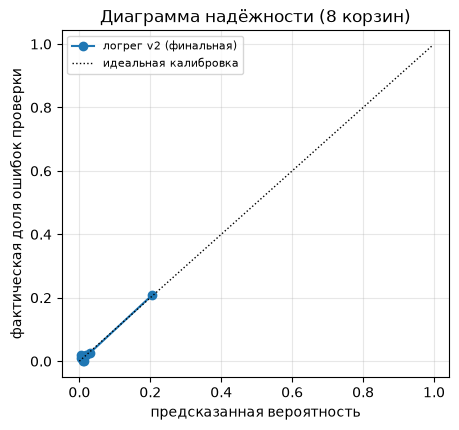

In [15]:
def ece(y_true, p, n_bins=8):
    y_true, p = np.asarray(y_true), np.asarray(p)
    return sum(len(b) / len(p) * abs(y_true[b].mean() - p[b].mean()) for b in np.array_split(np.argsort(p), n_bins))

print(f"доля ошибок {y.mean():.3f}; средняя вероятность {p_main.mean():.3f}; ECE {ece(y, p_main):.3f}; Brier {brier_score_loss(y, p_main):.4f}")
from sklearn.calibration import CalibratedClassifierCV
for method in ("sigmoid", "isotonic"):
    p_cal = oof(lambda: CalibratedClassifierCV(MODELS[FINAL](), method=method, cv=3), F)
    print(f"  + {method:8s}: ECE {ece(y, p_cal):.3f}; Brier {brier_score_loss(y, p_cal):.4f}; ROC-AUC {roc_auc_score(y, p_cal):.3f}")
bins = np.array_split(np.argsort(p_main), 8)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot([p_main[b].mean() for b in bins], [y.values[b].mean() for b in bins], "o-", label=FINAL)
lim = max(p_main.max(), .3); ax.plot([0, lim], [0, lim], "k:", lw=1, label="идеальная калибровка")
ax.set_xlabel("предсказанная вероятность"); ax.set_ylabel("фактическая доля ошибок проверки")
ax.set_title("Диаграмма надёжности (8 корзин)"); ax.legend(fontsize=8); ax.grid(alpha=.3); plt.show()

Логистическая регрессия откалибрована «по построению»; Платт и изотоническая калибровка на 32 примерах не улучшают её
заметно, поэтому систему не усложняем. ECE здесь сама шумная: в каждой корзине 3–4 ошибки.

## 6. Порог: Learn then Test

**Риск** — доля всех задач, где проверка ошиблась и куратор этого не увидел (= 1 − итоговое совпадение). Он не убывает
при смягчении порога. Процедура Learn then Test (Angelopoulos и др., 2021): для порогов от самого строгого (всё
куратору, риск 0) к мягким проверяем гипотезу «риск > α» точным биномиальным тестом (верхняя граница Клоппера–Пирсона
по всем N задачам) и останавливаемся на первой неудаче (fixed-sequence testing, поправка на множественность не нужна).

**Чего эта процедура здесь НЕ гарантирует формально:** оценки — out-of-fold на тех же 883 задачах, на которых выбирались
признаки и модель; задачи сгруппированы по работам; α выбиралось, видя таблицу ниже. Поэтому гарантия — ориентир,
подкреплённый вложенной CV полного конвейера (раздел 4) и кластерным bootstrap (ниже); проверка — H3 на test.

In [16]:
def point(p, y_true, t):
    y_true, auto = np.asarray(y_true), p <= t
    return {"к куратору": 1 - auto.mean(), "пропущено ошибок проверки": int(y_true[auto].sum()),
            "итоговое совпадение": 1 - y_true[auto].sum() / len(y_true)}

rows = []
for alpha in (0.01, 0.015, 0.02, 0.025, 0.03):
    for delta in (0.05, 0.1):
        t = ltt_threshold(p_main, y.values, alpha, delta)
        rows.append({"α": alpha, "δ": delta, "порог": t, **point(p_main, y.values, t)})
pd.DataFrame(rows).round(4)

,α,δ,порог,к куратору,пропущено ошибок проверки,итоговое совпадение
0,0.010,0.05,0.0064,0.6535,3,0.9966
1,0.010,0.10,0.0175,0.3194,4,0.9955
2,0.015,0.05,0.0428,0.1359,7,0.9921
3,0.015,0.10,0.0457,0.1291,8,0.9909
4,0.020,0.05,0.0607,0.0940,10,0.9887
5,0.020,0.10,0.0633,0.0725,11,0.9875
6,0.025,0.05,0.0705,0.0532,14,0.9841
7,0.025,0.10,0.1241,0.0351,15,0.9830
8,0.030,0.05,0.4442,0.0260,17,0.9807
9,0.030,0.10,0.4810,0.0227,19,0.9785


In [17]:
k_at = int(y.values[p_main <= t_star].sum())
nxt = np.sort(np.unique(p_main))[np.searchsorted(np.sort(np.unique(p_main)), t_star) + 1]
k_next = int(y.values[p_main <= nxt].sum())
print(f"порог {t_star:.4f} (α = {ALPHA}, δ = {DELTA}): пропущено {k_at}, верхняя граница риска {cp_upper(k_at, len(y), DELTA):.4f}")
print(f"следующее значение оценки {nxt:.4f}: пропущено было бы {k_next}, граница {cp_upper(k_next, len(y), DELTA):.4f}")

rnd, works = np.random.default_rng(0), df.work.values
idx = {w: np.where(works == w)[0] for w in np.unique(works)}
st = pd.DataFrame([point(p_main[s], y.values[s], t_star) for s in
                   (np.concatenate([idx[w] for w in rnd.choice(list(idx), len(idx))]) for _ in range(2000))])
for c in ["к куратору", "итоговое совпадение"]:
    print(f"  {c}: {point(p_main, y.values, t_star)[c]:.3f}  95% ДИ по работам [{st[c].quantile(.025):.3f}; {st[c].quantile(.975):.3f}]")
print(f"  доля bootstrap-выборок, где итоговое совпадение < 1 − α: {(st['итоговое совпадение'] < 1 - ALPHA).mean():.3f}")

порог 0.0633 (α = 0.02, δ = 0.1): пропущено 11, верхняя граница риска 0.0187
следующее значение оценки 0.0705: пропущено было бы 14, граница 0.0227
  к куратору: 0.072  95% ДИ по работам [0.038; 0.121]
  итоговое совпадение: 0.988  95% ДИ по работам [0.981; 0.994]
  доля bootstrap-выборок, где итоговое совпадение < 1 − α: 0.018


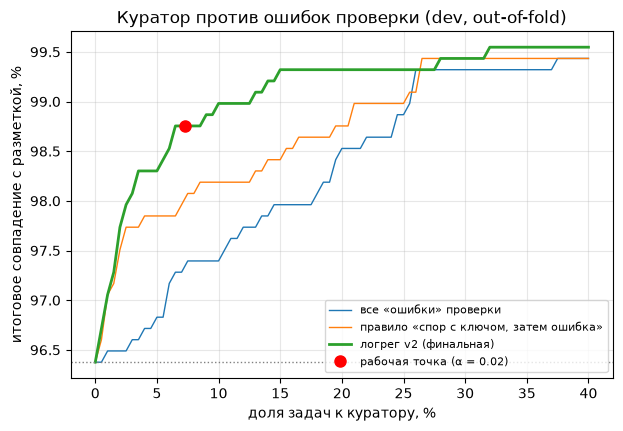

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
grid = np.linspace(0, 0.4, 81)
for name, s_ in {"все «ошибки» проверки": BASE["все «ошибки» проверки"],
                 "правило «спор с ключом, затем ошибка»": BASE["спор с ключом, затем «ошибка»"], FINAL: p_main}.items():
    ax.plot(100 * grid, [100 * routed_accuracy(y, s_, b) for b in grid], label=name, lw=2 if name == FINAL else 1)
pt = point(p_main, y.values, t_star)
ax.plot(100 * pt["к куратору"], 100 * pt["итоговое совпадение"], "ro", ms=8, label=f"рабочая точка (α = {ALPHA})")
ax.axhline(100 * (1 - y.mean()), color="grey", ls=":", lw=1)
ax.set_xlabel("доля задач к куратору, %"); ax.set_ylabel("итоговое совпадение с разметкой, %")
ax.set_title("Куратор против ошибок проверки (dev, out-of-fold)"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.savefig("risk_coverage_dev.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Финальная модель

Финальный предиктор — **среднее 100 моделей фолдов** (5 фолдов × 20 повторов): ровно те модели, на выходах которых
выбран порог (cross-fitting), поэтому порог переносится на новые данные без сдвига шкалы. Вложенная CV в разделе 4
проверяет именно такой перенос. Модели и порог замораживаются перед test (команда — в TEST_PROTOCOL.md).

In [19]:
import sklearn
p_check, fold_models = oof(MODELS[FINAL], F, keep=True)
assert np.allclose(p_check, p_main)
pickle.dump({"models": fold_models, "features": tf.FEATURES, "system": "google_gemini-3.8-flash@low_key",
             "sklearn": sklearn.__version__}, open("trust_model.pkl", "wb"))
json.dump({"alpha": ALPHA, "delta": DELTA, "threshold": float(t_star), "model": FINAL,
           "dev": {k: float(v) for k, v in point(p_main, y.values, t_star).items()}},
          open("trust_threshold.json", "w"), ensure_ascii=False, indent=1)
print(f"сохранено: {len(fold_models)} моделей, порог {t_star:.4f} → ml/trust_model.pkl, ml/trust_threshold.json")

сохранено: 100 моделей, порог 0.0633 → ml/trust_model.pkl, ml/trust_threshold.json


## 8. Итоги (dev, out-of-fold) и чувствительность к ошибкам куратора

In [20]:
pt = point(p_main, y.values, t_star)
auto = p_main <= t_star
real_err_at_curator = int(((df["label"].astype(int) == 0) & ~auto).sum())
summary = pd.DataFrame([
    {"система": "проверка без куратора", "к куратору": 0.0, "итоговое совпадение": 1 - y.mean()},
    {"система": "куратор смотрит все «ошибки» проверки", "к куратору": pe.mean(),
     "итоговое совпадение": 1 - ((pe == 0) & (y == 1)).sum() / len(y)},
    {"система": f"модель доверия, α = {ALPHA}", "к куратору": pt["к куратору"], "итоговое совпадение": pt["итоговое совпадение"]},
])
print(summary.round(3).to_string(index=False))
# задачи из списка проверки без метки (начата и брошена / зачёркнута / не решена): в метриках их нет, но в работе
# они тоже получат вердикт; по «списку от репетитора» таких будет не меньше
wall = pd.read_csv("../data/features_wide_all.csv")
un = wall[(wall.split == "dev") & wall.label.isna()].reset_index(drop=True)
Fu = tf.build(un)
to_cur_un = (tf.predict(fold_models, Fu) > t_star) | Fu[f"{tf.MAIN}__pred_error"].isna()
n_all = len(df) + len(un)
print(f"\nзадач без метки в списке проверки: {len(un)}; вердикт «ошибка / не решено» у {int((Fu[f'{tf.MAIN}__pred_error'] == 1).sum())}, "
      f"к куратору {int(to_cur_un.sum())}")
print(f"нагрузка на куратора с их учётом: ({int((~auto).sum())} + {int(to_cur_un.sum())}) / {n_all} = "
      f"{(int((~auto).sum()) + int(to_cur_un.sum())) / n_all:.1%}; из них «подтвердить, что не решено» — "
      f"{int(to_cur_un.sum()) / n_all:.1%}")
print(f"\nЕсли куратор сам пропускает долю r настоящих ошибок учеников в своих задачах "
      f"(у него {int((~auto).sum())} задач, из них с ошибкой ученика {real_err_at_curator}):")
for r in (0, 0.05, 29 / 231):
    wrong = y.values[auto].sum() + r * real_err_at_curator
    print(f"  r = {r:.1%}: итоговое совпадение {1 - wrong / len(y):.3f}")

                              система  к куратору  итоговое совпадение
                проверка без куратора       0.000                0.964
куратор смотрит все «ошибки» проверки       0.284                0.993
             модель доверия, α = 0.02       0.072                0.988

задач без метки в списке проверки: 54; вердикт «ошибка / не решено» у 54, к куратору 52
нагрузка на куратора с их учётом: (64 + 52) / 937 = 12.4%; из них «подтвердить, что не решено» — 5.5%

Если куратор сам пропускает долю r настоящих ошибок учеников в своих задачах (у него 64 задач, из них с ошибкой ученика 39):
  r = 0.0%: итоговое совпадение 0.988
  r = 5.0%: итоговое совпадение 0.985
  r = 12.6%: итоговое совпадение 0.982


r = 12,6% — доля ошибок, которые проверяющий-человек пропустил в dev (29 из 231): это пессимистичная оценка, потому что
куратор смотрит уже отобранные подозрительные задачи с подсказкой системы.

**Задачи «не решено».** Признак «тревога без названных ошибок» оценён в режиме, где список задач взят из разметки: там
почти каждая задача решена, и «не решено» чаще всего значит, что проверка не нашла решение. По списку заданных задач
от репетитора (`check.py --scope-file`) «не решено» будет в основном верным — такие задачи всё равно уходят куратору
(это безопасно: риск не растёт), но растёт нагрузка: на dev 12,4% вместо 7,2%, из них 5,5 п.п. — быстрые
подтверждения «решения нет». Разделить эти случаи без куратора — следующий шаг.

**Ограничения:** 32 ошибки проверки; признак v2 найден по dev; оценки разборчивости «плохо» (0) в dev не было ни разу —
на такой странице модель экстраполирует (вероятность растёт, задача уходит куратору — в безопасную сторону).

Главные выводы: (1) простая модель на 4 признаках не хуже сложных; правило на тех же сигналах даёт то же — ограничивают
данные и сигналы, а не модель; (2) второй голос не добавляет сигнала; (3) калибровка хорошая без дополнительных процедур;
(4) порог выбран Learn then Test и подкреплён вложенной CV (включая выбор v1/v2 внутри фолда) и кластерным bootstrap;
(5) потолок задаёт распознавание. Окончательные цифры — после test (TEST_RESULTS.md).